In [1]:
import numpy as np
import pandas as pd

In [2]:
d=pd.read_excel("AB.xlsx")

In [7]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              30000 non-null  int64         
 1   name                            29992 non-null  str           
 2   host_id                         30000 non-null  int64         
 3   host_name                       29988 non-null  str           
 4   neighbourhood_group             30000 non-null  str           
 5   neighbourhood                   30000 non-null  str           
 6   latitude                        30000 non-null  float64       
 7   longitude                       30000 non-null  float64       
 8   room_type                       30000 non-null  str           
 9   price                           30000 non-null  int64         
 10  minimum_nights                  30000 non-null  int64         
 11  number_of_rev

In [8]:
d["room_type"].value_counts()

room_type
Entire home/apt    15584
Private room       13790
Shared room          626
Name: count, dtype: int64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

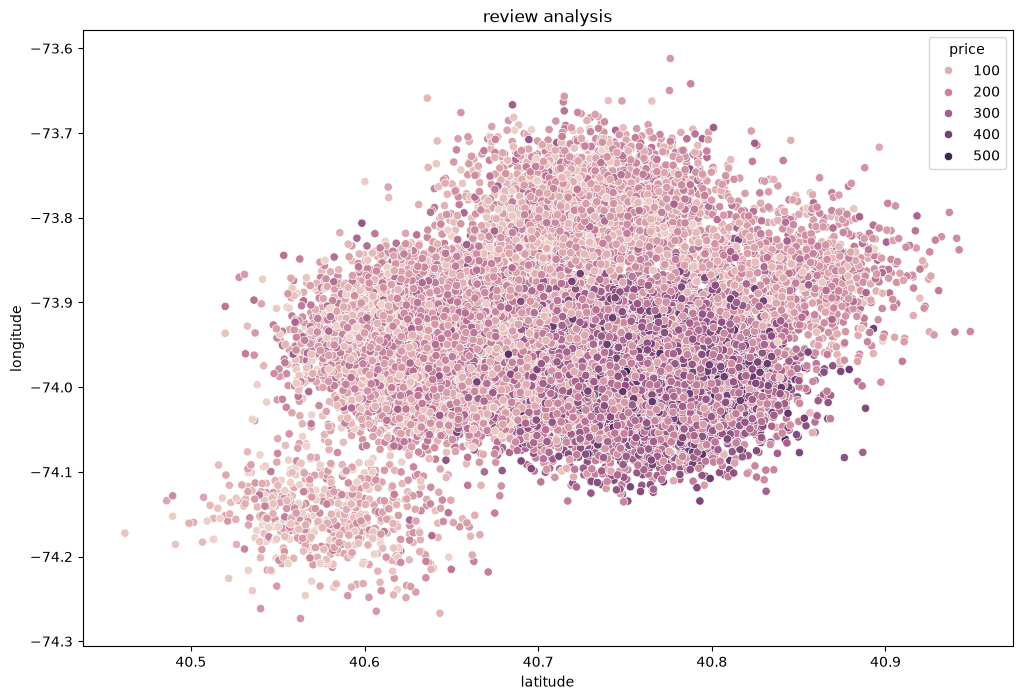

In [10]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=d, 
    x="latitude", 
    y="longitude", 
    hue="price"
)
plt.title("review analysis")
plt.xlabel("latitude")
plt.ylabel("longitude")
plt.show()



In [11]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=d, 
    x="latitude", 
    y="longitude", 
    hue="last_review"
)
plt.title("review analysis")
plt.xlabel("latitude")
plt.ylabel("longitude")
plt.show()

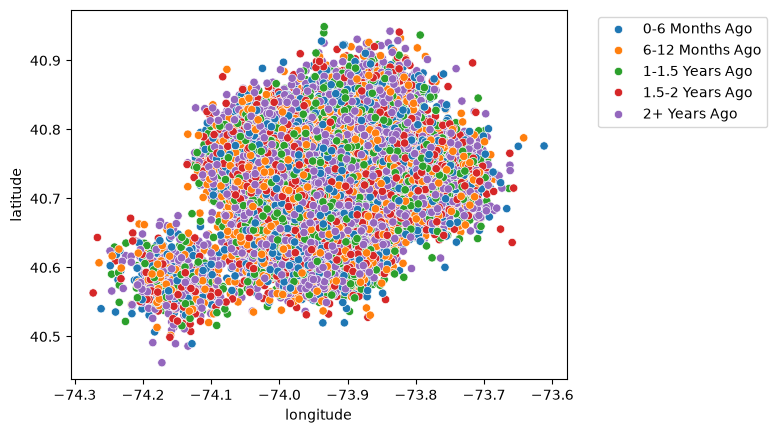

In [12]:
days_old = (d['last_review'].max() - d['last_review']).dt.days

d['review_gap'] = pd.cut(
    days_old,
    bins=[-1, 180, 365, 545, 730, np.inf], 
    labels=['0-6 Months Ago', '6-12 Months Ago', '1-1.5 Years Ago', '1.5-2 Years Ago', '2+ Years Ago']
)
sns.scatterplot(data=d, x="longitude", y="latitude", hue="review_gap")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

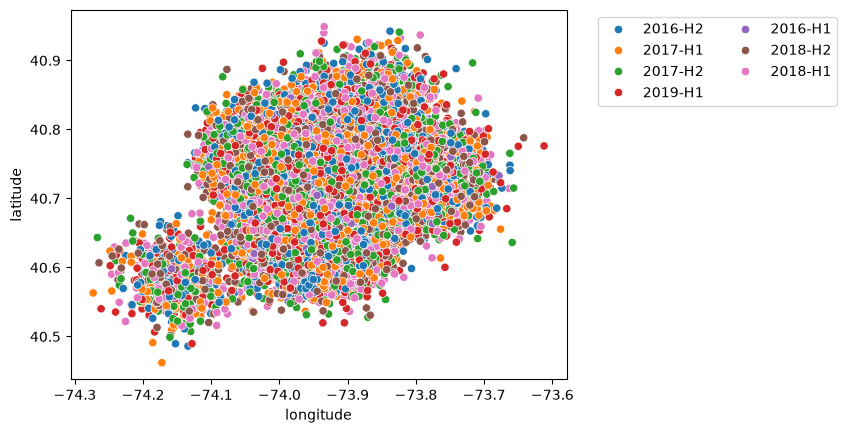

In [13]:
d['half_year'] = d['last_review'].dt.year.astype(str) + "-H" + ((d['last_review'].dt.month - 1) // 6 + 1).astype(str)

# Plot it
sns.scatterplot(data=d, x="longitude", y="latitude", hue="half_year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()

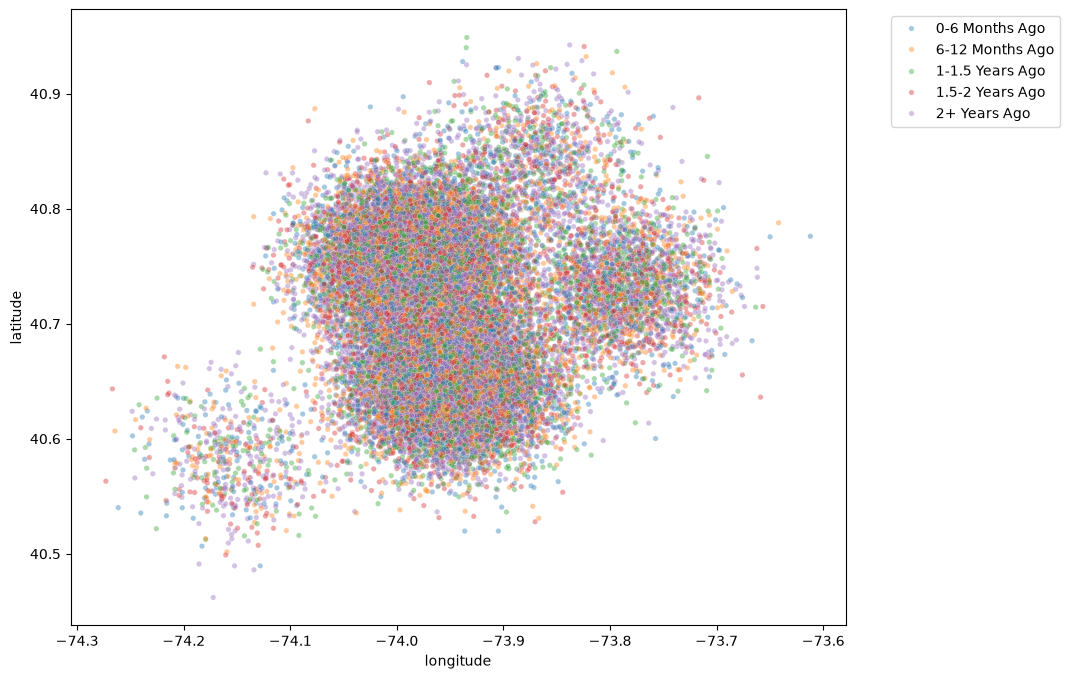

In [14]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=d, 
    x="longitude", 
    y="latitude", 
    hue="review_gap", 
    alpha=0.4,   # Makes the dots 60% transparent
    s=15         # Makes the dots much smaller
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

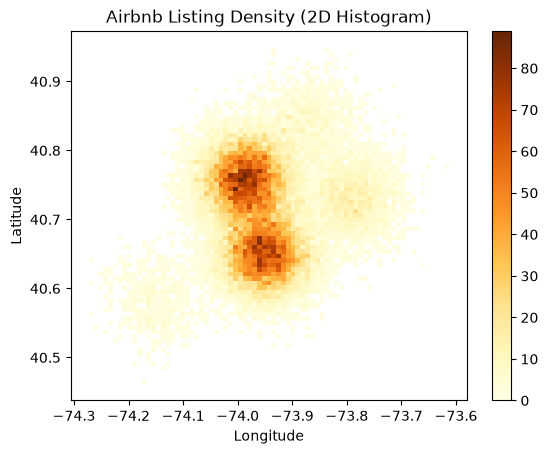

In [15]:
sns.histplot(
    data=d, 
    x="longitude", 
    y="latitude", 
    bins=75,          
    cbar=True,        
    cmap="YlOrBr"     
)

plt.title("Airbnb Listing Density (2D Histogram)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_demo=TfidfVectorizer(
    stop_words="english",
    max_features=20
)

features=d["name"].fillna("").astype(str)
features_to_data=tfidf_demo.fit_transform(features)
print("TF-IDF matrix shape:",features_to_data.shape)
print("Example vocabulary:")
print(list(tfidf_demo.get_feature_names_out()))

TF-IDF matrix shape: (30000, 20)
Example vocabulary:
['apt', 'bedford', 'brooklyn', 'bushwick', 'crown', 'east', 'entire', 'greenpoint', 'heights', 'home', 'park', 'private', 'room', 'slope', 'stuyvesant', 'sunset', 'upper', 'village', 'west', 'williamsburg']


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_preprocessor=Pipeline([
    ("Imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [6]:
numeric_features=[
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]
text_features=[
    "room_type",
    "neighbourhood_group"
]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, text_features),
        ("text_name", TfidfVectorizer(stop_words='english', max_features=100), 'name') 
    ],
    remainder="drop"
)

print("Full preprocessor successfully created!")


Full preprocessor successfully created!


In [7]:
d['name'] = d['name'].fillna("")

X_processed = preprocessor.fit_transform(d)

print("Feature matrix shape:", X_processed.shape)

Feature matrix shape: (30000, 59)


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = d.drop('price', axis=1)
y = d['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)

linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())  
])

linear_pipeline.fit(X_train, y_train)

predictions = linear_pipeline.predict(X_test)

print("TF-IDF + Linear Regression trained successfully!")
print("R-squared (R2):", round(r2_score(y_test, predictions), 3))
print("Mean Absolute Error (MAE): ", round(mean_absolute_error(y_test, predictions), 2))

TF-IDF + Linear Regression trained successfully!
R-squared (R2): 0.665
Mean Absolute Error (MAE):  42.35


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = d.drop('price', axis=1)
y = d['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) 
])

rf_pipeline.fit(X_train, y_train)

predictions = rf_pipeline.predict(X_test)

print("TF-IDF + Random Forest Regression trained successfully!")
print("R-squared (R2):", round(r2_score(y_test, predictions), 3))
print("Mean Absolute Error (MAE): ", round(mean_absolute_error(y_test, predictions), 2))

TF-IDF + Random Forest Regression trained successfully!
R-squared (R2): 0.674
Mean Absolute Error (MAE):  42.02


In [23]:
pip install shap lime

Note: you may need to restart the kernel to use updated packages.


In [17]:
try:
    import shap
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.model_selection import train_test_split
    
    # 1. Update data source and target variable
    shap_features = numeric_features
    X_shap = d[shap_features].copy() # Using 'd' instead of 'work'
    y_shap = d["price"].copy()       # Predicting 'price', not interest_level
    
    # 2. Split data (Removed 'stratify')
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        X_shap,
        y_shap,
        test_size=0.20,
        random_state=42
        # You cannot use stratify=y_shap on continuous regression numbers!
    )
    
    shap_imputer = SimpleImputer(strategy="median")
    Xs_train_imp = shap_imputer.fit_transform(Xs_train)
    Xs_test_imp = shap_imputer.transform(Xs_test)
    
    # 3. Swap Classifier for Regressor
    shap_rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    shap_rf.fit(Xs_train_imp, ys_train)
    
    shap_explainer = shap.TreeExplainer(shap_rf)
    
    # 4. Pro-tip: Only calculate SHAP for a sample of the test set
    print("Calculating SHAP values... (this might take a minute)")
    shap_values = shap_explainer.shap_values(Xs_test_imp[:500]) 
    
    print("SHAP calculation completed successfully!")
    
except Exception as e:
    print("SHAP could not run:", e)

C:\Users\ABY\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values... (this might take a minute)
SHAP calculation completed successfully!


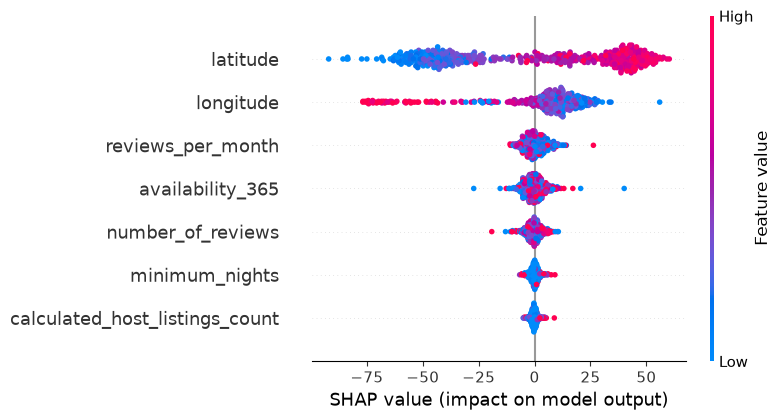

In [25]:
try:
    shap.summary_plot(
        shap_values,
        Xs_test_imp[:500],  # Match this to the 500 rows we calculated earlier!
        feature_names=shap_features,  # Fixed the typo here
        show=True
    )
except Exception as e:
    print("SHAP plotting format may differ in this SHAP version.")
    print("Error:", e)

In [26]:
try:
    from lime.lime_tabular import LimeTabularExplainer
    
    # 1. Update mode to regression and drop class_names
    lime_explainer = LimeTabularExplainer(
        Xs_train_imp,
        feature_names=shap_features,
        mode="regression",  # Swapped from "classification"
        random_state=42
        # Removed class_names=sorted(y.unique()) because regression has no discrete classes
    )
    
    # 2. Use standard predict instead of predict_proba
    lime_exp = lime_explainer.explain_instance(
        Xs_test_imp[0],
        shap_rf.predict,  # Swapped from predict_proba
        num_features=8
    )
    
    print("LIME explanation for Listing #0:")
    for feature, weight in lime_exp.as_list():
        print(f"{feature}: {weight:.4f}")
        
except Exception as e:
    print("LIME could not run:", e)

LIME explanation for Listing #0:
latitude > 40.76: 48.9896
longitude <= -74.00: 20.7511
120.00 < availability_365 <= 181.00: -0.9998
calculated_host_listings_count > 3.00: -0.9037
0.36 < reviews_per_month <= 0.72: 0.8100
minimum_nights <= 1.00: 0.6594
number_of_reviews > 39.00: -0.1477


In [18]:
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameters to test
# Because the model is inside a Pipeline named 'regressor', 
# you must use the 'regressor__' prefix for every parameter.
param_grid = {
    'regressor__n_estimators': [50, 100],          # Test fewer trees to see if we can save space
    'regressor__max_depth': [10, 20, 30],          # Test different depth limits
    'regressor__min_samples_leaf': [2, 5, 10]      # Test different leaf constraints
}

# 2. Configure the Grid Search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # We want the configuration with the lowest dollar error
    cv=3,                               # 3-fold cross-validation (keeps run-time manageable)
    n_jobs=-1,                          # Use all CPU cores
    verbose=2                           # Prints out live updates so you know it hasn't frozen
)

# 3. Launch the search (This will train 54 different models!)
print("Starting Grid Search... You can watch your CPU cores spike now!")
grid_search.fit(X_train, y_train)

# 4. Reveal the winning configuration
print("\n--- Grid Search Completed ---")
print("Best Parameters Found:", grid_search.best_params_)

# 5. Evaluate the absolute best model on your test data
final_best_model = grid_search.best_estimator_
best_predictions = final_best_model.predict(X_test)

print("\nBest Model R-squared (R2):", round(r2_score(y_test, best_predictions), 3))
print("Best Model MAE: ", round(mean_absolute_error(y_test, best_predictions), 2))

Starting Grid Search... You can watch your CPU cores spike now!
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- Grid Search Completed ---
Best Parameters Found: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 10, 'regressor__n_estimators': 100}

Best Model R-squared (R2): 0.683
Best Model MAE:  41.36


In [19]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [20]:
import joblib

# 1. Extract the absolute best pipeline from the grid search
optimized_rf_model = grid_search.best_estimator_

# 2. Save it with level 3 compression to clear the 25 MB GitHub limit
joblib.dump(optimized_rf_model, "airbnb_optimized.joblib", compress=3)

print("Optimized, GitHub-ready model saved successfully!")

Optimized, GitHub-ready model saved successfully!


In [13]:
loaded_model = joblib.load("airbnb.joblib")

In [14]:
test_predictions=loaded_model.predict(
    X_test.head(5)
)
print("Predictions from reloaded model:")
print(test_predictions)

Predictions from reloaded model:
[331.51 332.77 177.3  135.2  219.76]


In [15]:
new_listing = pd.DataFrame({
    "name": ["Luxury apartment with a beautiful view"],
    "neighbourhood_group": ["Manhattan"],
    "latitude": [40.7831],                
    "longitude": [-73.9712],               
    "room_type": ["Entire home/apt"],
    "minimum_nights": [1],
    "number_of_reviews": [1],
    "reviews_per_month": [0],
    "calculated_host_listings_count": [0],
    "availability_365": [0]
})

prediction = loaded_model.predict(new_listing)
print("Predicted Nightly Price: $", round(prediction[0], 2))

Predicted Nightly Price: $ 222.72
